In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import requests
import numpy as np

# 设置中文字体，防止图表中的中文显示为方块
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows用黑体
# plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] # Mac用户请使用这一行
plt.rcParams['axes.unicode_minus'] = False

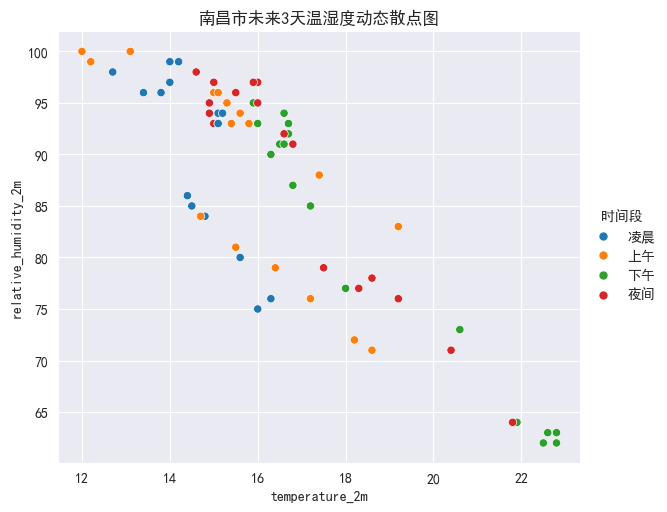

In [2]:
# 1. 获取数据
url = "https://api.open-meteo.com/v1/forecast"
params = {
    "latitude": 28.68,
    "longitude": 115.89,
    "hourly": "temperature_2m,relative_humidity_2m", # [cite: 7]
    "forecast_days": 3, # [cite: 8]
    "timezone": "Asia/Shanghai" # [cite: 9]
}
response = requests.get(url, params=params).json()
df_1 = pd.DataFrame(response['hourly'])
df_1['time'] = pd.to_datetime(df_1['time'])

# 2. 数据处理与时间段划分
df_1["时间段"] = df_1["time"].dt.hour.apply(
    lambda x: "凌晨" if x < 6 else "上午" if x < 12 else "下午" if x < 18 else "夜间"
)

# 3. 绘制动态双变量散点图 [cite: 4, 5]
sns.relplot(
    data=df_1,
    x="temperature_2m",
    y="relative_humidity_2m",
    hue="时间段",
    kind="scatter",
    height=5,
    aspect=1.2
)
plt.title("南昌市未来3天温湿度动态散点图")
plt.show()

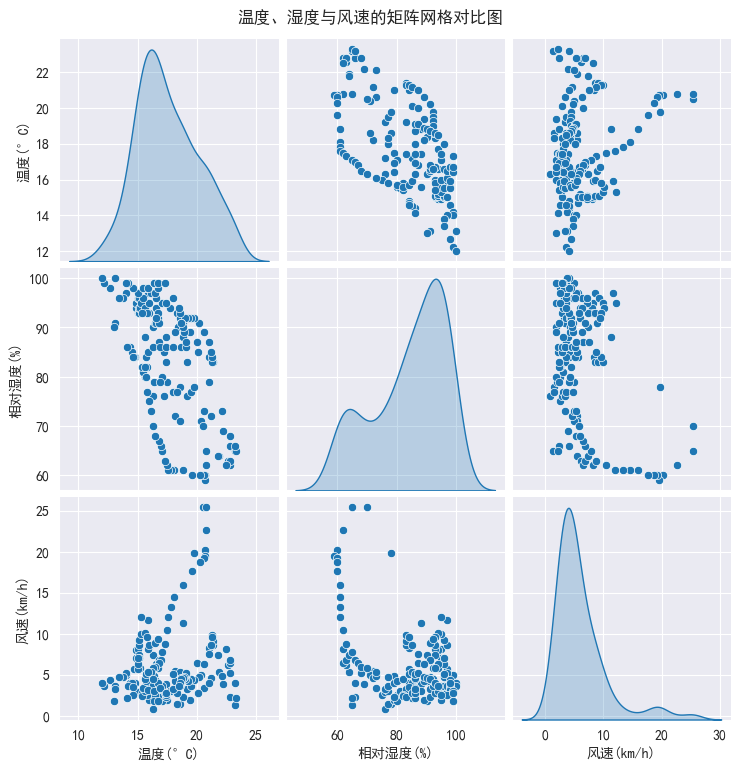

In [3]:
# 1. 获取7天数据
params_1_2 = {
    "latitude": 28.68,
    "longitude": 115.89,
    "hourly": "temperature_2m,relative_humidity_2m,wind_speed_10m", # [cite: 16]
    "forecast_days": 7, # [cite: 17]
    "timezone": "Asia/Shanghai" # [cite: 18]
}
df_2 = pd.DataFrame(requests.get(url, params=params_1_2).json()['hourly'])

# 2. 绘制矩阵网格图 [cite: 13, 14]
df_2.columns = ['时间', '温度(°C)', '相对湿度(%)', '风速(km/h)'] # 重命名以便图表显示
sns.pairplot(df_2[['温度(°C)', '相对湿度(%)', '风速(km/h)']], diag_kind="kde") #
plt.suptitle("温度、湿度与风速的矩阵网格对比图", y=1.02)
plt.show()

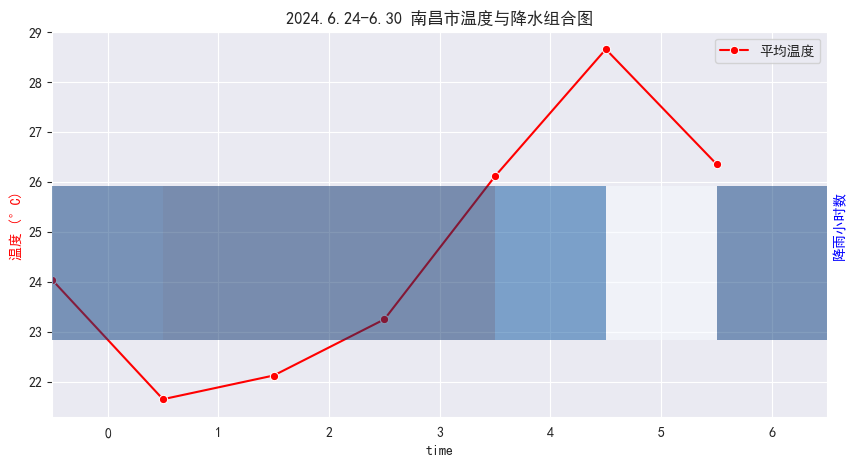

In [4]:
# 1. 获取历史数据 (使用Open-Meteo历史API)
archive_url = "https://archive-api.open-meteo.com/v1/archive"
params_1_3 = {
    "latitude": 28.68,
    "longitude": 115.89,
    "start_date": "2024-06-24", # [cite: 24]
    "end_date": "2024-06-30", # [cite: 24]
    "hourly": "temperature_2m,precipitation", # [cite: 23]
    "timezone": "Asia/Shanghai"
}
df_3_raw = pd.DataFrame(requests.get(archive_url, params=params_1_3).json()['hourly'])
df_3_raw['time'] = pd.to_datetime(df_3_raw['time'])

# 2. 创建周数据框架 [cite: 26]
week_df = df_3_raw.groupby(pd.Grouper(key="time", freq="D")).agg({
    "temperature_2m": "mean", # [cite: 28]
    "precipitation": lambda x: sum(x > 0)  # 降雨小时数 [cite: 29]
}).reset_index()
week_df['time'] = week_df['time'].dt.strftime('%m-%d')

# 3. 创建双轴图表 [cite: 21]
fig, ax1 = plt.subplots(figsize=(10, 5))

# 左轴：温度折线图 [cite: 21]
sns.lineplot(data=week_df, x="time", y="temperature_2m", ax=ax1, color="red", marker="o", label="平均温度")
ax1.set_ylabel("温度 (°C)", color="red")

# 右轴：降水强度 [cite: 21]
ax2 = ax1.twinx()
# 使用 heatmap 形式展示 1D 降水数据
sns.heatmap(week_df[['precipitation']].T, cmap="Blues", cbar=False, ax=ax2, alpha=0.5, zorder=0)
ax2.set_ylabel("降雨小时数", color="blue")
ax2.set_yticks([]) # 隐藏热力图默认y刻度
ax2.set_ylim(-0.5, 2) # 调整热力图高度占比

plt.title("2024.6.24-6.30 南昌市温度与降水组合图")
plt.show()

C:\Users\Wei\AppData\Local\Temp\ipykernel_32488\459144158.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_4, x="天气类型", palette="Set2", ax=ax1, order=sorted_categories)
C:\Users\Wei\AppData\Local\Temp\ipykernel_32488\459144158.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df_4, x="天气类型", y="temperature_2m_max", palette="Set2", ax=ax2, order=sorted_categories)


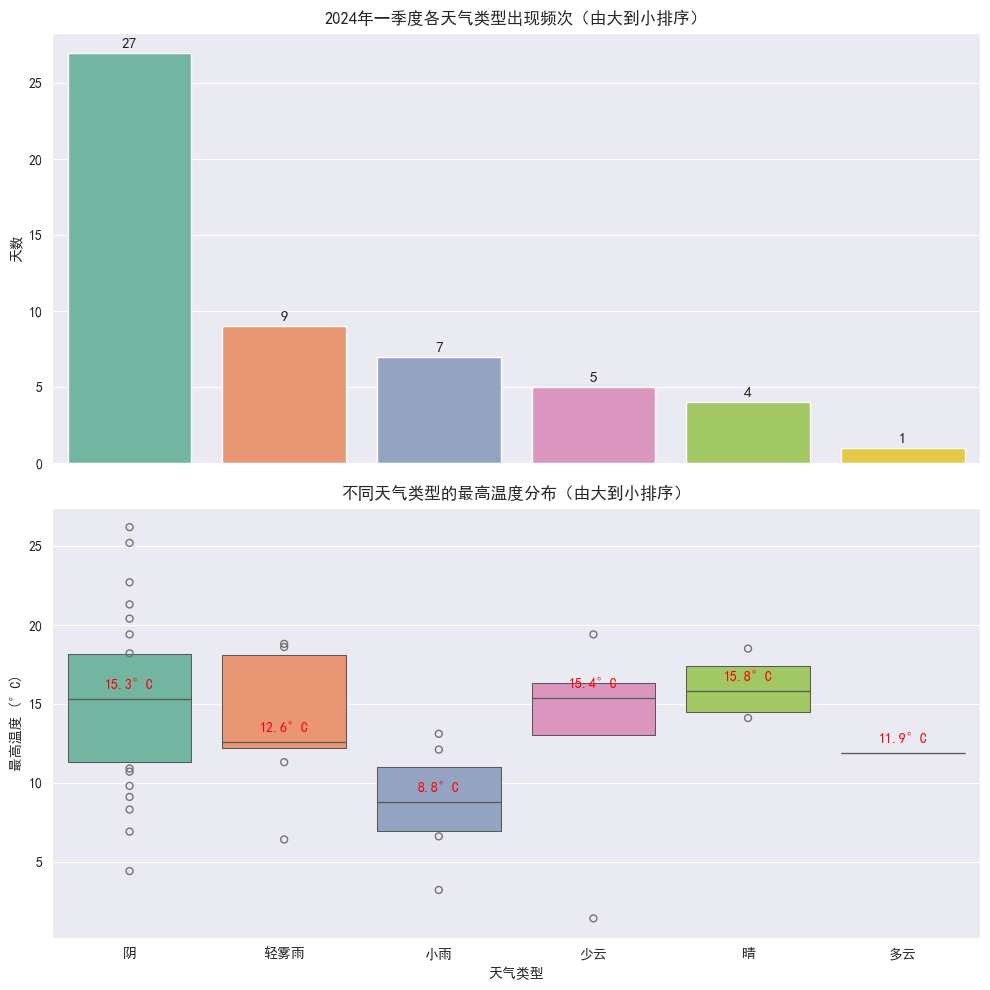

In [14]:
# 数据获取与预处理
archive_url = "https://archive-api.open-meteo.com/v1/archive"
params_2_1 = {
    "latitude": 28.68,
    "longitude": 115.89,
    "start_date": "2024-01-01",
    "end_date": "2024-03-31",
    "daily": "weather_code,temperature_2m_max",
    "timezone": "Asia/Shanghai"
}
df_4 = pd.DataFrame(requests.get(archive_url, params=params_2_1).json()['daily'])

# WMO天气代码转换
weather_map = {
    0: "晴", 1: "少云", 2: "多云",
    3: "阴", 45: "雾", 51: "轻雾雨",
    61: "小雨", 80: "阵雨"
}
df_4["天气类型"] = df_4["weather_code"].map(weather_map)
df_4 = df_4[df_4["天气类型"].notna()]  # 清洗无效数据

# 核心：按天气类型出现频次由大到小排序
freq_counts = df_4["天气类型"].value_counts().sort_values(ascending=False)
sorted_categories = freq_counts.index.tolist()  # 排序后的天气类型列表

# 绘制图表（按频次降序排列）
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# 1. 天气类型频次条形图（指定排序顺序）
sns.countplot(data=df_4, x="天气类型", palette="Set2", ax=ax1, order=sorted_categories)
ax1.set_title("2024年一季度各天气类型出现频次（由大到小排序）")
ax1.set_ylabel("天数")
# 添加频次数值标注
for patch in ax1.patches:
    height = patch.get_height()
    x_pos = patch.get_x() + patch.get_width() / 2
    ax1.text(x_pos, height + 0.2, f'{int(height)}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 2. 最高温度分布增强箱线图（同步排序顺序）
sns.boxenplot(data=df_4, x="天气类型", y="temperature_2m_max", palette="Set2", ax=ax2, order=sorted_categories)
ax2.set_title("不同天气类型的最高温度分布（由大到小排序）")
ax2.set_ylabel("最高温度 (°C)")
# 添加中位数数值标注
median_temp = df_4.groupby("天气类型")["temperature_2m_max"].median().reindex(sorted_categories)
for i, median_val in enumerate(median_temp):
    x_pos = ax2.get_xticks()[i]
    ax2.text(x_pos, median_val + 0.5, f'{median_val:.1f}°C', ha='center', va='bottom', fontsize=10, color='red', fontweight='bold')

plt.tight_layout()
plt.show()

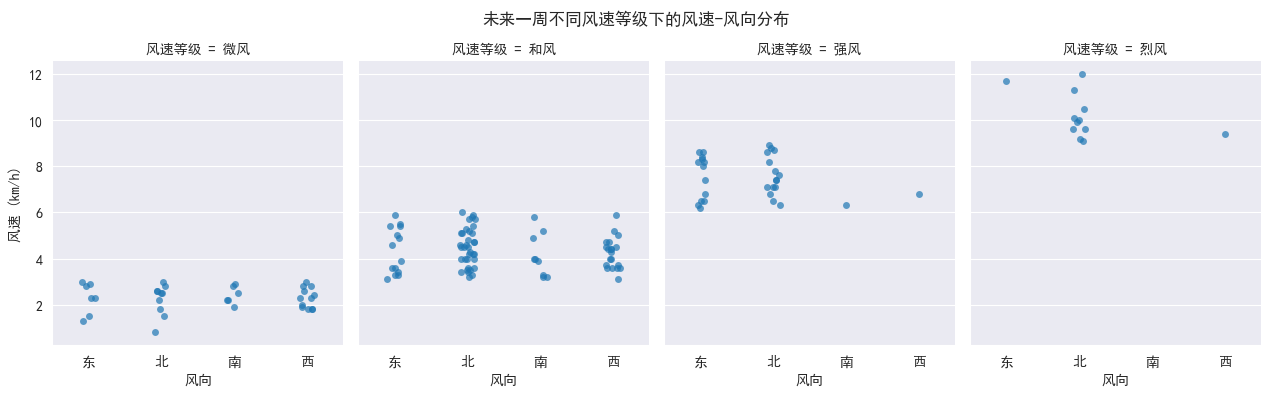

In [6]:
params_2_2 = {
    "latitude": 28.68,
    "longitude": 115.89,
    "hourly": "wind_direction_10m,wind_speed_10m", # [cite: 47]
    "forecast_days": 7, # [cite: 48]
    "timezone": "Asia/Shanghai"
}
df_5 = pd.DataFrame(requests.get(url, params=params_2_2).json()['hourly'])

# 风向4方位转换 [cite: 50]
df_5["风向"] = pd.cut(df_5["wind_direction_10m"],
                   bins=[0, 45, 135, 225, 315, 360],
                   labels=["北", "东", "南", "西", "北"],
                   ordered=False, include_lowest=True) # [cite: 51, 52, 53, 54]

# 风速分级 [cite: 55]
df_5["风速等级"] = pd.cut(df_5["wind_speed_10m"],
                     bins=[0, 3, 6, 9, 12],
                     labels=["微风", "和风", "强风", "烈风"]) # [cite: 56, 57, 58]

# 使用 FacetGrid 分面
g = sns.FacetGrid(df_5, col="风速等级", height=4, aspect=0.8) #
g.map_dataframe(sns.stripplot, x="风向", y="wind_speed_10m", jitter=True, alpha=0.7) #
g.set_axis_labels("风向", "风速 (km/h)")
plt.subplots_adjust(top=0.85)
g.fig.suptitle("未来一周不同风速等级下的风速-风向分布")
plt.show()

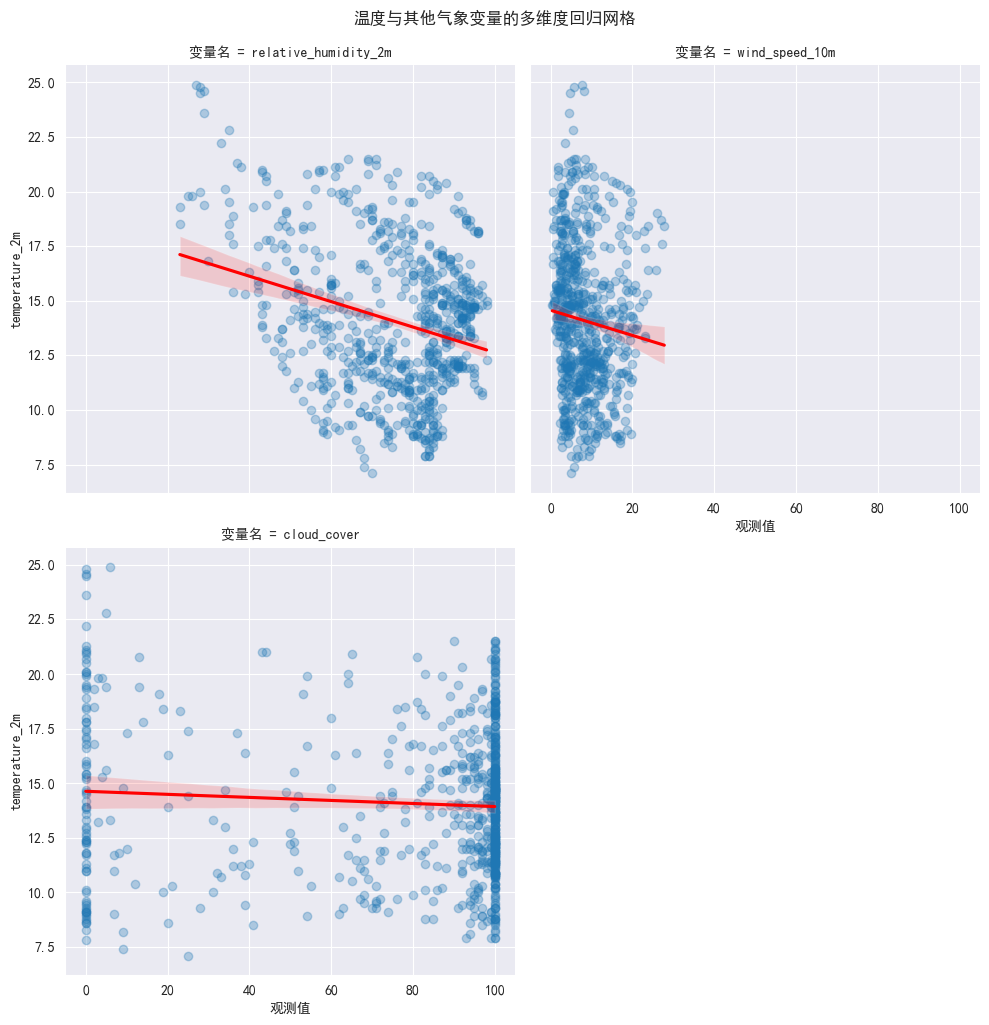

In [15]:
params_3_1 = {
    "latitude": 28.68,
    "longitude": 115.89,
    "hourly": "temperature_2m,relative_humidity_2m,wind_speed_10m,cloud_cover", # [cite: 63, 64]
    "past_days": 30, # [cite: 65]
    "forecast_days": 0,
    "timezone": "Asia/Shanghai"
}
df_6 = pd.DataFrame(requests.get(url, params=params_3_1).json()['hourly']).dropna()

# 宽表转长表以适配 lmplot
df_melted = df_6.melt(id_vars=["time", "temperature_2m"],
                      value_vars=["relative_humidity_2m", "wind_speed_10m", "cloud_cover"],
                      var_name="变量名", value_name="观测值")

# 使用 lmplot 创建回归网格 [cite: 61]
sns.lmplot(data=df_melted, x="观测值", y="temperature_2m",
           col="变量名", col_wrap=2,
           scatter_kws={"alpha": 0.3}, line_kws={"color": "red"})
plt.suptitle("温度与其他气象变量的多维度回归网格", y=1.02)
plt.show()

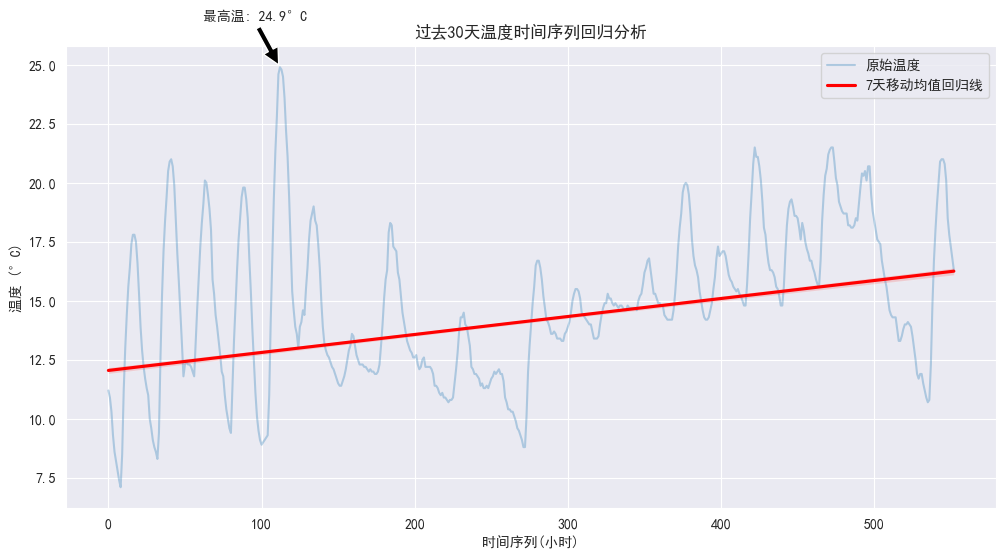

In [8]:
df_7 = df_6.copy()
# 创建移动平均列 [cite: 69]
df_7["7d_MA"] = df_7["temperature_2m"].rolling(window=7*24).mean() # [cite: 70]
df_7 = df_7.dropna().reset_index()

plt.figure(figsize=(12, 6))
# 组合趋势线与置信区间 [cite: 68]
sns.lineplot(data=df_7, x=df_7.index, y="temperature_2m", alpha=0.3, label="原始温度")
sns.regplot(data=df_7, x=df_7.index, y="7d_MA", scatter=False, color="red", label="7天移动均值回归线")

# 标注极值点 [cite: 68]
max_idx = df_7["temperature_2m"].idxmax()
max_temp = df_7["temperature_2m"].max()
plt.annotate(f'最高温: {max_temp}°C',
             xy=(max_idx, max_temp), xytext=(max_idx-50, max_temp+2),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.title("过去30天温度时间序列回归分析")
plt.xlabel("时间序列(小时)")
plt.ylabel("温度 (°C)")
plt.legend()
plt.show()

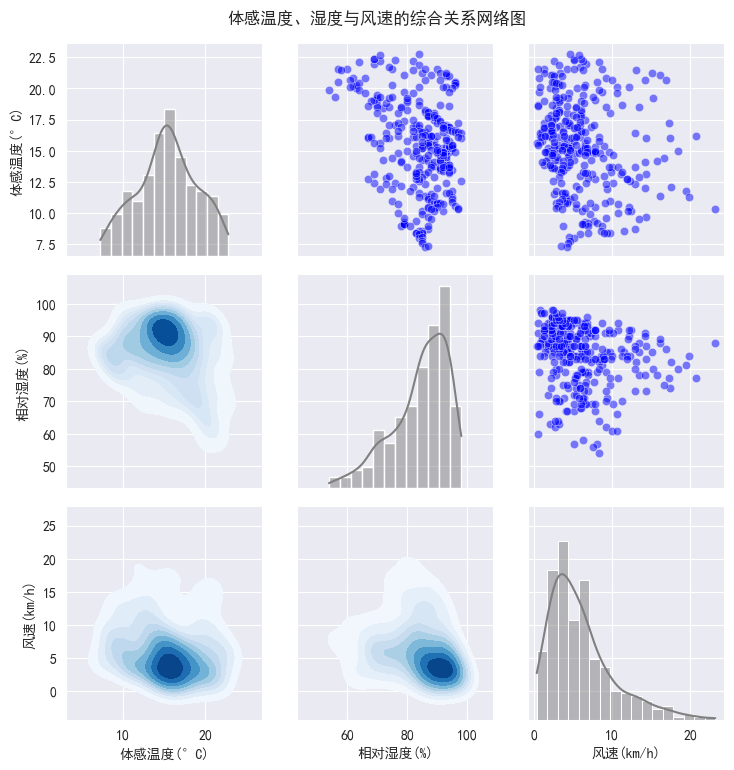

In [9]:
params_3_3 = {
    "latitude": 28.68,
    "longitude": 115.89,
    "hourly": "apparent_temperature,relative_humidity_2m,wind_speed_10m", # [cite: 78, 79]
    "past_days": 14, # [cite: 80]
    "forecast_days": 0,
    "timezone": "Asia/Shanghai"
}
df_8 = pd.DataFrame(requests.get(url, params=params_3_3).json()['hourly']).dropna()
df_8 = df_8[['apparent_temperature', 'relative_humidity_2m', 'wind_speed_10m']]
df_8.columns = ['体感温度(°C)', '相对湿度(%)', '风速(km/h)']

# 使用 PairGrid 自定义网格结构 [cite: 73]
g = sns.PairGrid(df_8) # [cite: 73]
g.map_upper(sns.scatterplot, alpha=0.5, color="blue") # [cite: 74]
g.map_diag(sns.histplot, kde=True, color="gray") # [cite: 75]
g.map_lower(sns.kdeplot, cmap="Blues", fill=True) # [cite: 76]

g.fig.suptitle("体感温度、湿度与风速的综合关系网络图", y=1.02)
plt.show()